# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.
Removendo duplicatas, restam **1'812** entradas.


In [25]:
%%html
<link rel="stylesheet" href="./style.css">

In [26]:
import import_ipynb  # noqa: F401
from treatment import (  # type: ignore
    f3_categorical_columns,
    f3_df,
    f3_numerical_columns,
)


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes

from columns import target_columns
from data import dd_df, names_of_columns

In [ ]:
def plot_clusters_numeric_boxplot(
    data_frame: pd.DataFrame, cluster_column: str, numerical_columns: list[str]
):
    n = len(numerical_columns)

    fig, axes = plt.subplots(
        nrows=(n + 1) // 2, ncols=2, figsize=(14, 5 * ((n + 1) // 2))
    )

    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        sns.boxplot(data=data_frame, x=cluster_column, y=col, ax=ax)

        ax.set_title(f"{col} por cluster")
        ax.set_xlabel("Cluster")
        ax.set_ylabel(names_of_columns[col])

    # remove eixos vazios
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()
    plt.show()

In [29]:
def plot_clusters_categorical(
    data_frame: pd.DataFrame, cluster_column: str, categorical_columns: list[str]
):
    for col in categorical_columns:
        proportions = (
            pd.crosstab(data_frame[cluster_column], data_frame[col], normalize="index")
            * 100
        )

        ax = proportions.plot(kind="bar", figsize=(10, 5))

        ax.set_title(f"{col} por cluster")
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Proporção (%)")
        ax.legend(
            title=names_of_columns[col], bbox_to_anchor=(1.05, 1), loc="upper left"
        )

        plt.tight_layout()
        plt.show()

## K-Prototypes


In [30]:
features = f3_categorical_columns + f3_numerical_columns
clustered_df_by_kp = f3_df[features].copy()

# K-Prototypes expects categorical columns as strings
for col in f3_categorical_columns:
    clustered_df_by_kp[col] = clustered_df_by_kp[col].astype(str)

# Identify indexes of categorical indexes
indexes_of_categorical_columns = [
    clustered_df_by_kp.columns.get_loc(col) for col in f3_categorical_columns
]

# Set parameters
k_prototypes_protocol = KPrototypes(
    n_clusters=6, init="Cao", n_init=10, random_state=42
)

# Clustering
clusters = k_prototypes_protocol.fit_predict(
    clustered_df_by_kp.to_numpy(), categorical=indexes_of_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_by_kp["cluster"] = clusters

# Add target variables back for cluster analysis
clustered_df_by_kp["paddy_yield"] = f3_df.loc[clustered_df_by_kp.index, "paddy_yield"]
clustered_df_by_kp["trash"] = f3_df.loc[clustered_df_by_kp.index, "trash"]

# Revert scaling
clustered_df_by_kp.seed_rate = dd_df.loc[clustered_df_by_kp.index, "seed_rate"]
clustered_df_by_kp.paddy_yield = dd_df.loc[clustered_df_by_kp.index, "paddy_yield"]
clustered_df_by_kp.trash = dd_df.loc[clustered_df_by_kp.index, "trash"]


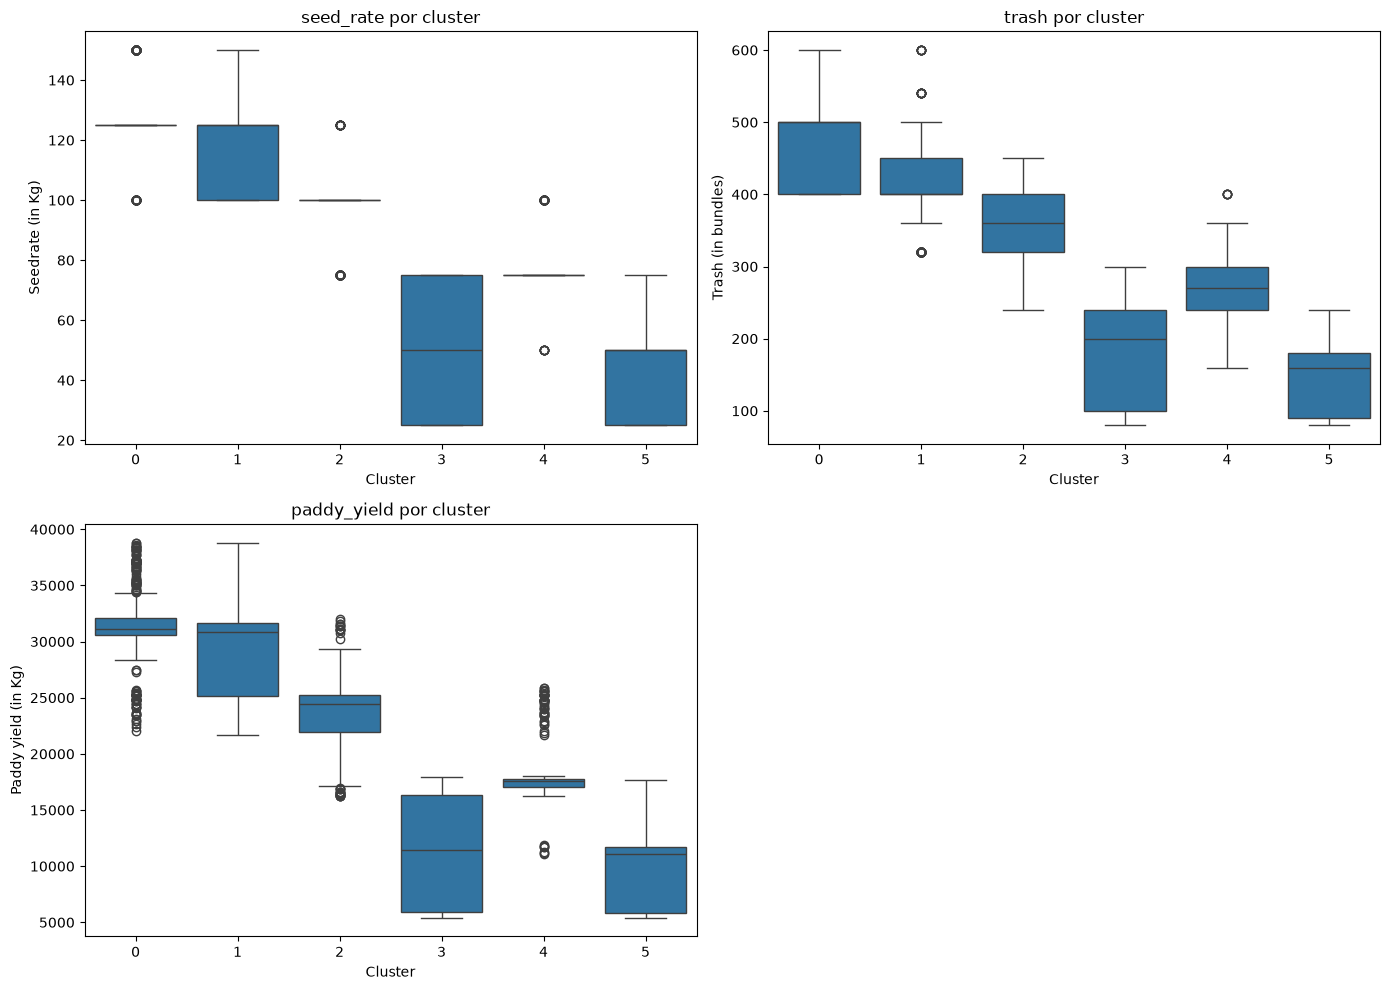

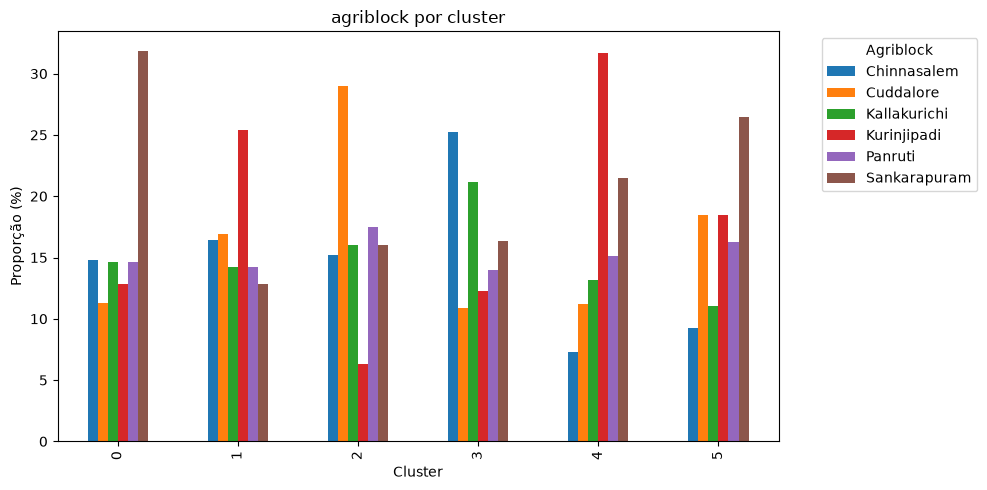

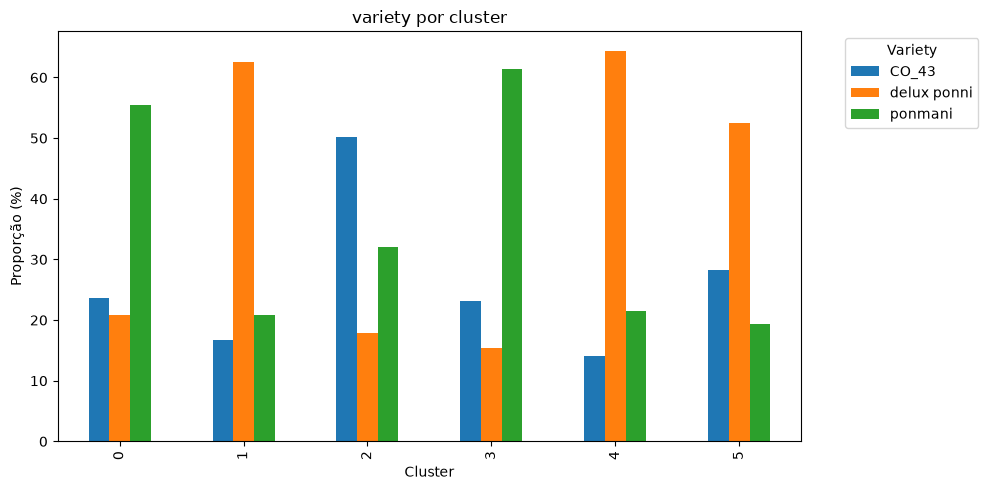

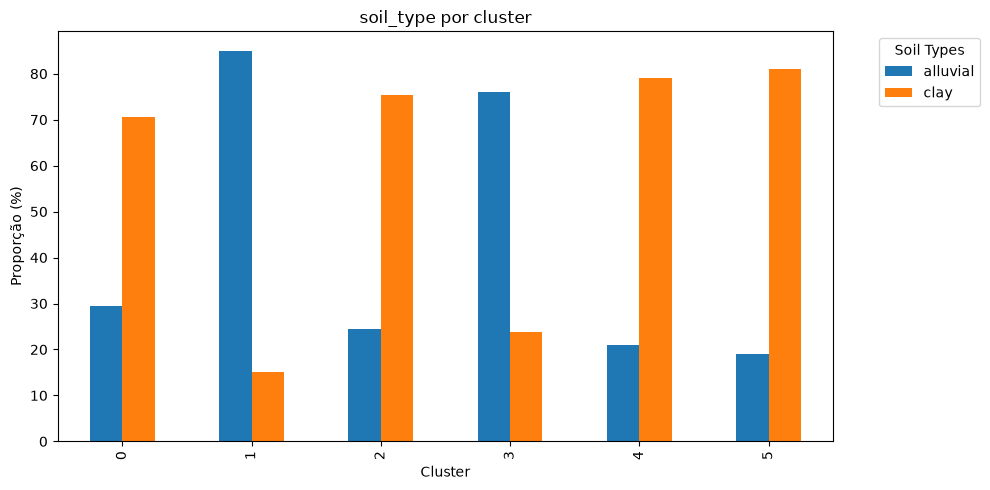

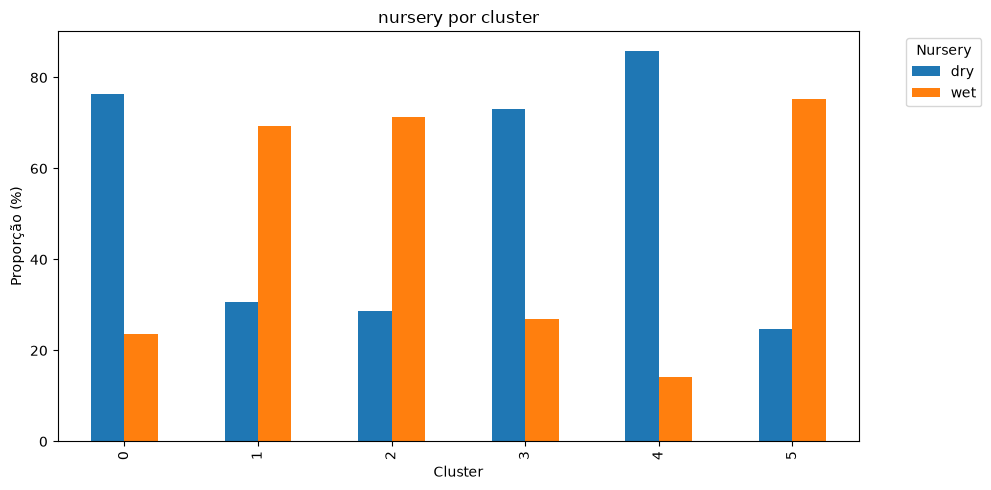

In [ ]:
plot_clusters_numeric_boxplot(
    data_frame=clustered_df_by_kp,
    cluster_column="cluster",
    numerical_columns=[*f3_numerical_columns, *target_columns],
)


plot_clusters_categorical(
    data_frame=clustered_df_by_kp,
    cluster_column="cluster",
    categorical_columns=f3_categorical_columns,
)

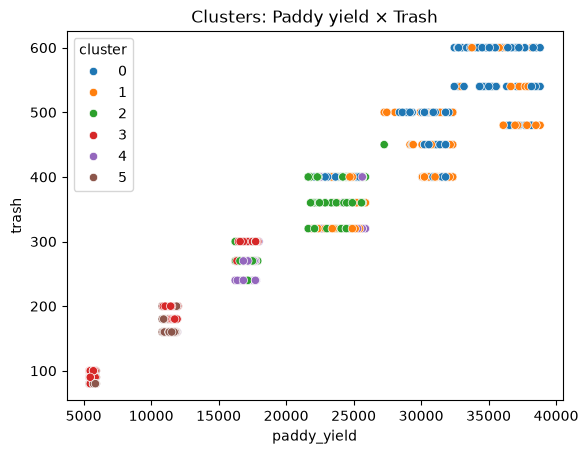

<Axes: xlabel='seed_rate', ylabel='paddy_yield'>

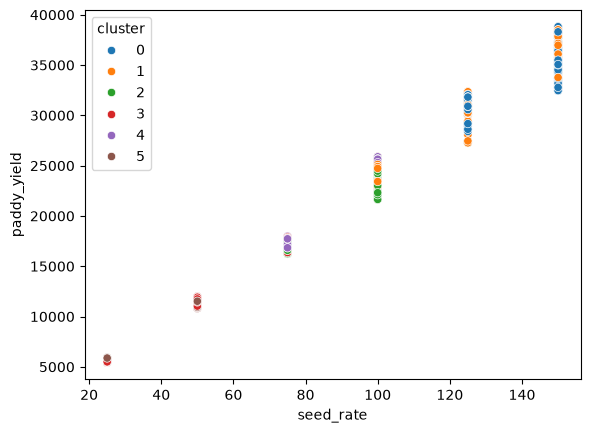

In [ ]:
sns.scatterplot(
    data=clustered_df_by_kp,
    x="paddy_yield",
    y="trash",
    hue="cluster",
    palette="tab10",
)
plt.title("Clusters: Paddy yield × Trash")
plt.show()

sns.scatterplot(
    data=clustered_df_by_kp,
    x="seed_rate",
    y="paddy_yield",
    hue="cluster",
    palette="tab10",
)
plt.title("Clusters: Paddy yield × Trash")
plt.show()
